# Small crystalline dataset

> Georgios Varnavides | Oct 21 2025  
>
> Sample: thin strontium titanate (STO)  
> Sampling conditions: Nyquist  
> Imaging conditions: 20 mrad, in-focus, defocus, coma, defocus + coma  

In [1]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets

import ase
import abtem
from pathlib import Path
import ase.build
import abtem

gold_on_mos2 = False
# abtem.config.set({'dask.lazy': False})

## STO Unitcell

We'll make an ASE Atoms object using Materials Project entry [mp-5229](https://next-gen.materialsproject.org/materials/mp-5229). Note this uses Wyckoff Positions and Spacegroups, but you can also export the CIF/POSCAR file if you prefer.

In [2]:
from ase.cluster import FaceCenteredCubic

surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1)]
layers = [15, 11, 5]
lc = 4.08

nanoparticle = FaceCenteredCubic("Au", surfaces, layers, latticeconstant=lc)



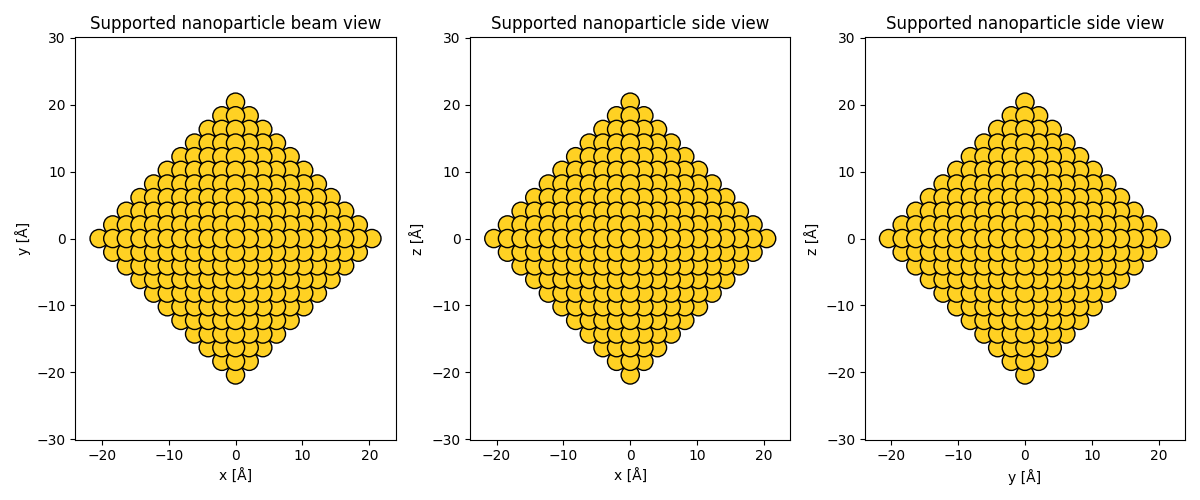

In [3]:



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

In [4]:
rotated_nanoparticle = nanoparticle.copy()

rotated_nanoparticle.rotate(45, "x")

y_angle = np.degrees(np.arctan(1 / np.sqrt(2)))

rotated_nanoparticle.rotate(y_angle, "y")

#| label: app:unit_cell_projections



In [5]:
centered_nanoparticle = rotated_nanoparticle.copy()

centered_nanoparticle.center(vacuum=0)

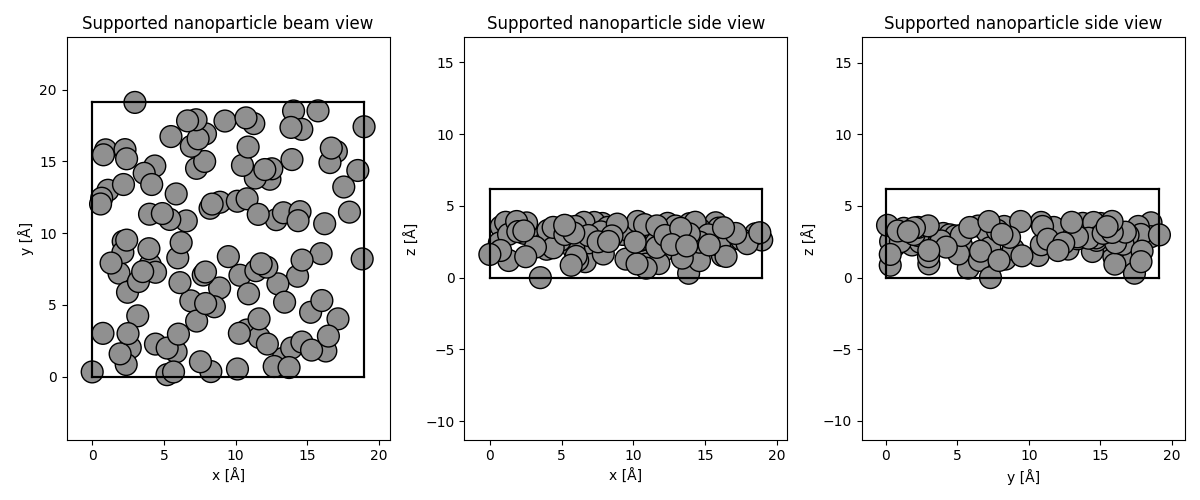

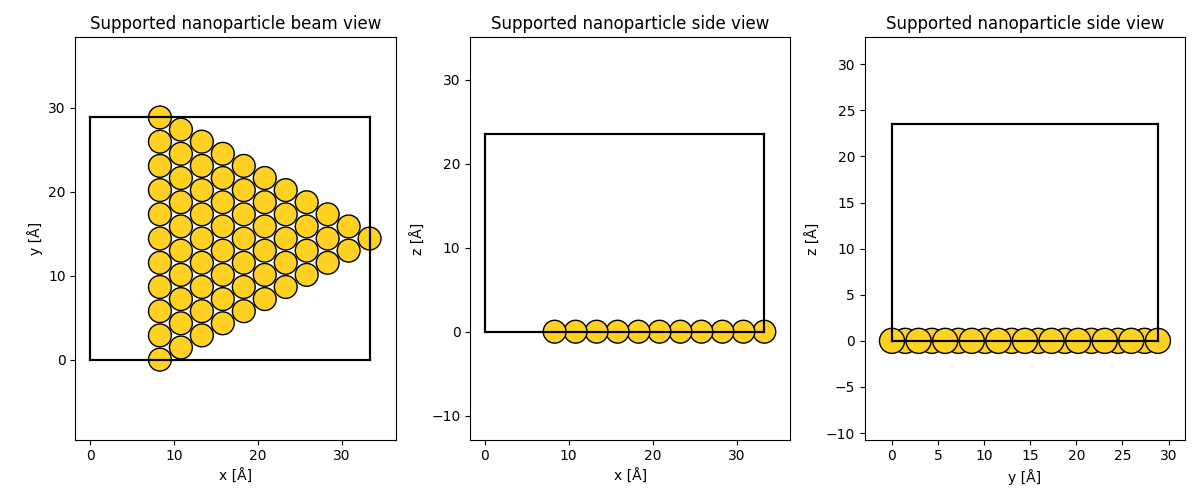

In [6]:
substrate = ase.build.bulk("C", cubic=True)

# repeat diamond structure
substrate = substrate * (5, 5, 1)

# displace atoms with a standard deviation of 50 % of the bond length
bl = 1.54  # Bond length
rng = np.random.default_rng(seed=10)
substrate.positions[:] += rng.normal(size=(len(substrate), 3)) * 0.5 * bl
substrate.center(vacuum=0)

mask = substrate.positions[:, 2] > 4
del substrate[np.where(mask)[0]]



fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    substrate,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    substrate,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    substrate,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

# wrap the atoms displaced outside the cell back into the cell
substrate.wrap()

cut_nanoparticle = centered_nanoparticle.copy()

# mask = cut_nanoparticle.positions[:, 2] < 20

# # # deletion *requires* providing the indices, i.e. boolean indexing does not work
# del cut_nanoparticle[np.where(mask)[0]]

# mask = cut_nanoparticle.positions[:, 1] < 20

# deletion *requires* providing the indices, i.e. boolean indexing does not work
# del cut_nanoparticle[np.where(mask)[0]]
# cut_nanoparticle.center()

mask = cut_nanoparticle.positions[:, 2] > 2
del cut_nanoparticle[np.where(mask)[0]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

In [7]:
# center nanoparticle relative to substrate
cut_nanoparticle.set_cell(substrate.cell)


# mask = cut_nanoparticle.positions[:, 2] > 5
# del cut_nanoparticle[np.where(mask)[0]]

cut_nanoparticle.center()

# shift nanoparticle in the z-direction
cut_nanoparticle.positions[:, 2] -= 27

supported_nanoparticle = cut_nanoparticle#+ substrate

supported_nanoparticle.center(axis=2, vacuum=5)
supported_nanoparticle.center(axis=1, vacuum=10)
supported_nanoparticle.center(axis=0, vacuum=10)

# Make x and y directions equal by adding vacuum to the shorter one
x_length = supported_nanoparticle.cell[0, 0]
y_length = supported_nanoparticle.cell[1, 1]
max_length = max(x_length, y_length)

if x_length < max_length:
    extra_vacuum = (max_length - x_length) / 2
    supported_nanoparticle.center(axis=0, vacuum=10 + extra_vacuum)

if y_length < max_length:
    extra_vacuum = (max_length - y_length) / 2
    supported_nanoparticle.center(axis=1, vacuum=10 + extra_vacuum)

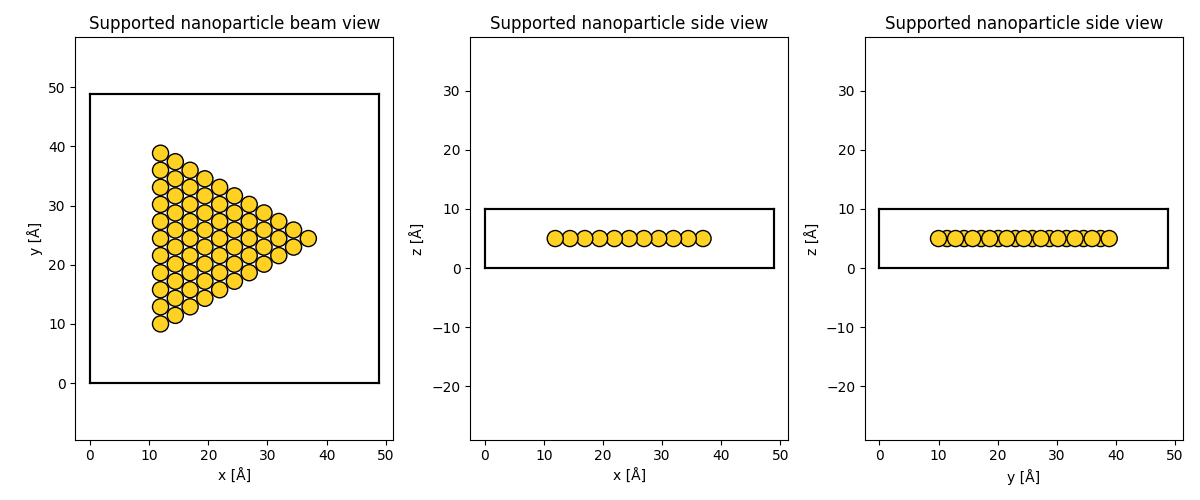

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

In [9]:
from ase.build import fcc111

lc = 4.08
supported_nanoparticle = fcc111('Au', size=(32, 36, 1), a=lc, vacuum=30.0, 
                     orthogonal=True)

## Potential 

We build the numeric representation of the atomic potentials.

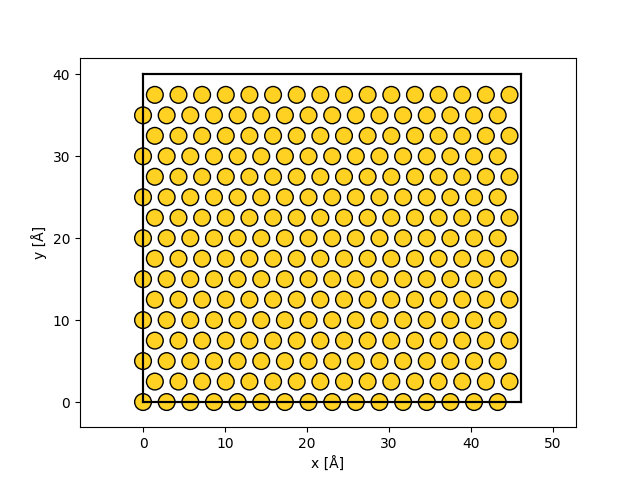

In [10]:
from ase.build import fcc111
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 1), a=lc, vacuum=30.0, orthogonal=False)
nanoparticle = abtem.orthogonalize_cell(unit_cell) * (8,4,1)
abtem.show_atoms(nanoparticle)
supported_nanoparticle = nanoparticle


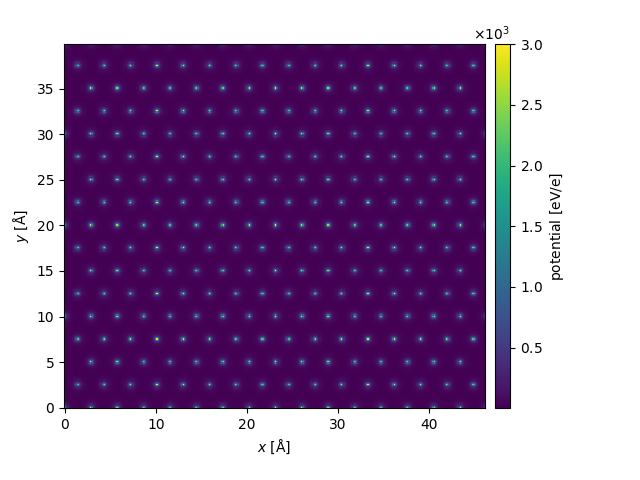

In [11]:
potential = abtem.Potential(
    supported_nanoparticle,
    sampling=8/64,
    slice_thickness= 2/4,
).build(
    lazy=False
)

ax = potential.show(
    cbar=True
);

x_min = 0
x_max = 43
y_min = 0
y_max = 43
gpts_xy = (48, 48)


## Probe

We use a converged probe with a few different aberrations.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

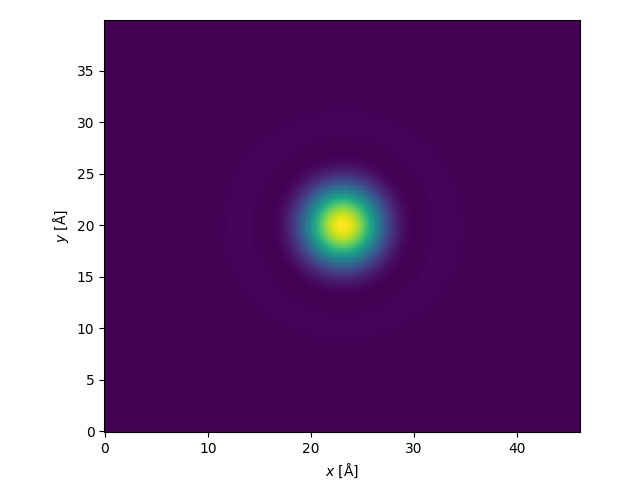

In [12]:
energy = 2.5e3 # eV
semiangle_cutoff = 20 # mrad
defocus = 00
astig =  0000
astig_angle = -0.8
spherical = 000000
aberrations = {
    "C10":defocus,
    "C21":astig,
    "phi21":astig_angle,
    "C30":spherical,
}

# 2x2 probes ensemble
probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    # device='gpu',
).match_grid(
    potential
)

probes.show(
    explode=True
)

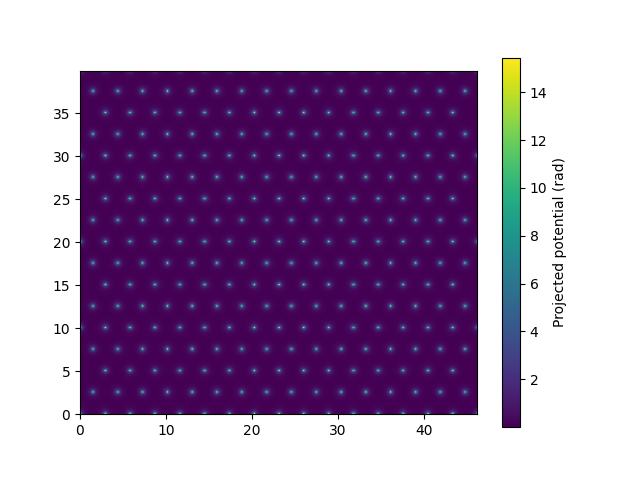

In [13]:
fig, ax = plt.subplots()
im = ax.imshow(potential.project().array.T * abtem.core.energy.energy2sigma(energy),extent=[0, potential.extent[0], 0, potential.extent[1]],origin='lower')
fig.colorbar(im, ax=ax, label='Projected potential (rad)')

247


tasks:   0%|          | 0/2 [00:00<?, ?it/s]

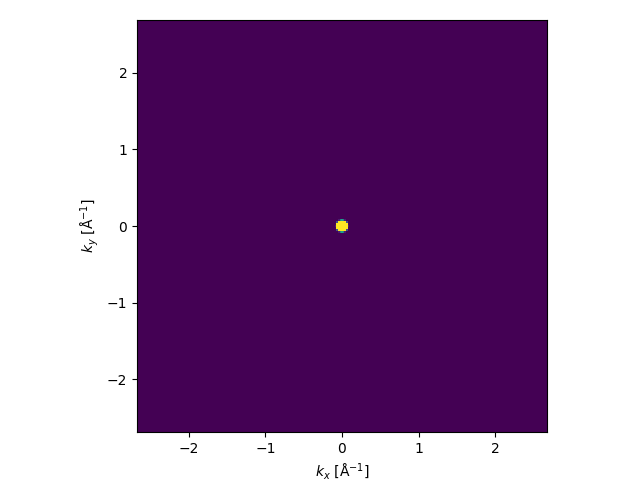

In [14]:
print(len(probes.build().diffraction_patterns(block_direct=False)))
probes.build().diffraction_patterns(block_direct=False).show()

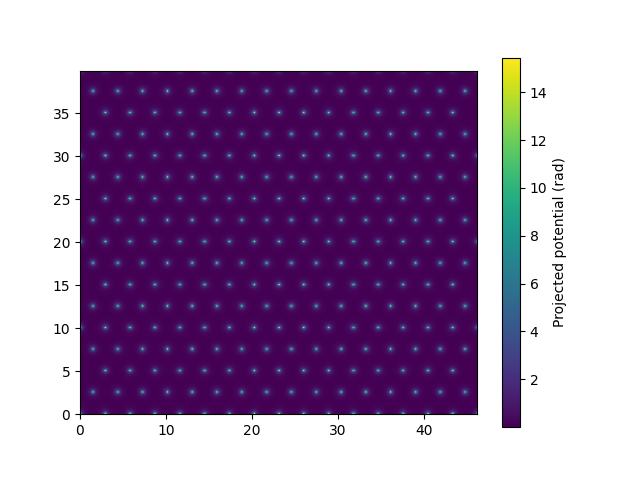

In [15]:
fig, ax = plt.subplots()
im = ax.imshow(potential.project().array.T * abtem.core.energy.energy2sigma(energy),extent=[0, potential.extent[0], 0, potential.extent[1]],origin='lower')
fig.colorbar(im, ax=ax, label='Projected potential (rad)')

## Manual Simulation

In [16]:
"""
Drop-in replacement for your notebook
Just replace the relevant cell with this code
"""

# =============================================================================
# STEP 1: Create a 48x48 grid scan
# =============================================================================
from abtem import GridScan

# Create the scan grid covering the entire potential extent
scan = GridScan(
    start=(0, 0),              # Start position in Angstroms
    end=potential.extent,       # End at the full extent of the potential
    gpts=(10,10),             # 48x48 grid points
)

print(f"Grid scan created:")
print(f"  Number of positions: {len(scan)}")
print(f"  Scan step size: {scan.sampling} Å")
print(f"  Total extent: {potential.extent} Å")

# =============================================================================
# STEP 2: Modified exit_wave_taylor_terms for 4D-STEM
# =============================================================================

def exit_wave_taylor_terms(potential, probe, orders=[0, 1, 2], sigma=None, scan=None):
    """
    Compute Taylor expansion terms - supports both single probe and 4D-STEM.
    
    Parameters
    ----------
    potential : abtem.Potential or 2D ndarray
        Projected potential V(r)
    probe : abtem.Probe or 2D ndarray
        Incident probe
    orders : list of int
        Taylor expansion orders to compute
    sigma : float, optional
        Interaction constant
    scan : abtem.GridScan, optional
        If provided, computes 4D-STEM dataset. If None, single probe at origin.
    
    Returns
    -------
    psi_k : dict
        If scan=None: {order: 2D array} - single diffraction pattern
        If scan provided: {order: 4D array (scan_y, scan_x, det_y, det_x)}
    """
    from numpy.fft import fft2, fftshift
    import math
    import abtem
    
    # Handle abTEM Potential object
    if hasattr(potential, 'project'):
        potential_array = potential.project().array
        if sigma is None:
            if hasattr(probe, 'energy'):
                sigma = abtem.core.energy.energy2sigma(probe.energy)
            else:
                raise ValueError("sigma must be provided")
    else:
        potential_array = potential
        if sigma is None:
            raise ValueError("sigma must be provided when using potential array")
    
    # Handle abTEM Probe object
    if hasattr(probe, 'build'):
        if scan is not None:
            # 4D-STEM mode: build probe at all scan positions
            print(f"Building {len(scan)} probe positions for 4D-STEM...")
            probe_waves = probe.build(scan=scan)
            is_4d = True
            scan_shape = probe_waves.array.shape[:2]
            detector_shape = probe_waves.array.shape[2:]
            print(f"  Scan grid: {scan_shape}")
            print(f"  Detector: {detector_shape}")
        else:
            # Single probe mode
            probe_wave = probe.build()
            probe_array = probe_wave.array
            is_4d = False
    else:
        probe_array = probe
        is_4d = False
    
    # Compute Taylor expansion
    psi_k = {}
    
    if is_4d:
        # 4D-STEM computation
        for n in orders:
            print(f"Computing order {n}...")
            psi_k[n] = np.zeros(scan_shape + detector_shape, dtype=complex)
            
            for i in range(scan_shape[0]):
                for j in range(scan_shape[1]):
                    probe_array = probe_waves.array[i, j]
                    
                    if n == 0:
                        psi_n = probe_array.copy()
                    else:
                        psi_n = probe_array * (1j * sigma * potential_array)**n / math.factorial(n)
                    
                    psi_k[n][i, j] = fftshift(fft2(psi_n))
            
            print(f'  psi_k[{n}].shape: {psi_k[n].shape}')
    else:
        # Single probe computation
        for n in orders:
            if n == 0:
                psi_n = probe_array.copy()
            else:
                psi_n = probe_array * (1j * sigma * potential_array)**n / math.factorial(n)
            
            psi_k[n] = fftshift(fft2(psi_n))
            print(f'psi_k[{n}].shape: {psi_k[n].shape}')
    
    return psi_k


# =============================================================================
# STEP 3: Use the function with the scan
# =============================================================================

print("\n" + "="*70)
print("COMPUTING 4D-STEM TAYLOR EXPANSION")
print("="*70)

# Compute with 4D-STEM scan
psi_k_terms = exit_wave_taylor_terms(
    potential=potential,
    probe=probes,
    orders=[0, 1, 2],
    scan=scan  # <-- This makes it 4D-STEM!
)


Grid scan created:
  Number of positions: 100
  Scan step size: (4.615993067585783, 3.9975672602221466) Å
  Total extent: (46.15993067585783, 39.975672602221465) Å

COMPUTING 4D-STEM TAYLOR EXPANSION
Building 100 probe positions for 4D-STEM...
  Scan grid: (10, 10)
  Detector: (370, 320)
Computing order 0...
  psi_k[0].shape: (10, 10, 370, 320)
Computing order 1...
  psi_k[1].shape: (10, 10, 370, 320)
Computing order 2...
  psi_k[2].shape: (10, 10, 370, 320)


[0, 1, 2]

4D-STEM dataset shape: (10, 10, 370, 320)
  This is: (10x10 scan) × (370x320 detector)

Diffraction pattern at scan position (28, 28):
  Shape: (370, 320)
  Max intensity: 9.94e-03


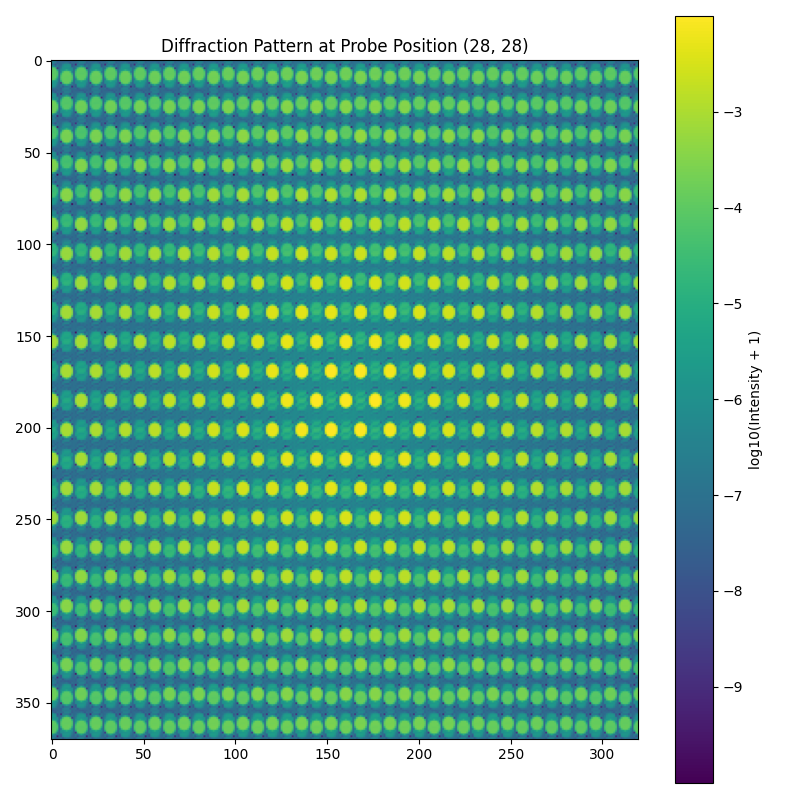

In [17]:

# Compute diffraction intensities
def diffraction_intensity_from_orders(psi_k, include_cross_terms=True):
    """Compute intensity - works for both 2D and 4D arrays."""
    import numpy as np
    
    first_key = list(psi_k.keys())[0]
    I = np.zeros(psi_k[first_key].shape, dtype=float)
    I0 = np.zeros(psi_k[first_key].shape, dtype=float)
    I1= np.zeros(psi_k[first_key].shape, dtype=float)
    I10 = np.zeros(psi_k[first_key].shape, dtype=float)
    I2 = np.zeros(psi_k[first_key].shape, dtype=float)
    I02= np.zeros(psi_k[first_key].shape, dtype=float)
    I12 = np.zeros(psi_k[first_key].shape, dtype=float)
    orders = sorted(psi_k.keys())
    print(orders)
    if include_cross_terms:
        for n in orders:
            for m in orders:
                cross = np.real(np.conj(psi_k[n]) * psi_k[m])
                I += cross
                if n==1 and m==0 or n==0 and m==1:
                    I10 += cross
                if n ==0 and m == 0:
                    I0 += cross
                if n ==1 and m ==1:
                    I1 += cross
                if n==0 and m==2 or n==2 and m==0:
                    I02+=cross
                if m==2 and n==2:
                    I2+=cross
                if n==1 and m==2 or n==2 and m==1:
                    I12+=cross
    else:
        for n in orders:
            direct = np.abs(psi_k[n])**2
            I += direct

    
    return I, I0, I1, I10, I2, I02, I12

I_4d, I0_4d, I1_4d, I10_4d, I2_4d, I02_4d, I12_4d = diffraction_intensity_from_orders(psi_k_terms)

print(f"\n4D-STEM dataset shape: {I_4d.shape}")
print(f"  This is: ({I_4d.shape[0]}x{I_4d.shape[1]} scan) × ({I_4d.shape[2]}x{I_4d.shape[3]} detector)")

# =============================================================================
# STEP 4: Extract diffraction pattern at position (28, 28)
# =============================================================================

diffraction_at_28_28 = I_4d[3, 3]
print(f"\nDiffraction pattern at scan position (28, 28):")
print(f"  Shape: {diffraction_at_28_28.shape}")
print(f"  Max intensity: {diffraction_at_28_28.max():.2e}")

# You can now visualize it
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(diffraction_at_28_28 + 1e-10), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()
plt.show()

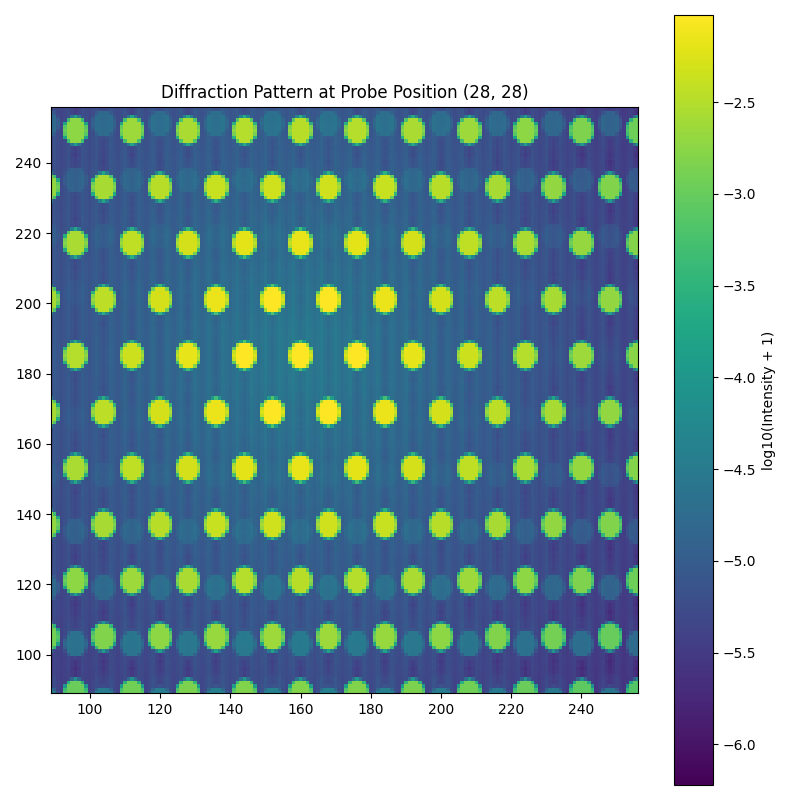

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(I_4d.mean(axis=(0,1)) + 1e-10), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.xlim(I_4d[0,0].shape[0]/2-96, I_4d[0,0].shape[1]/2+96)
plt.ylim(I_4d[0,0].shape[0]/2-96, I_4d[0,0].shape[1]/2+96)

plt.tight_layout()
plt.show()

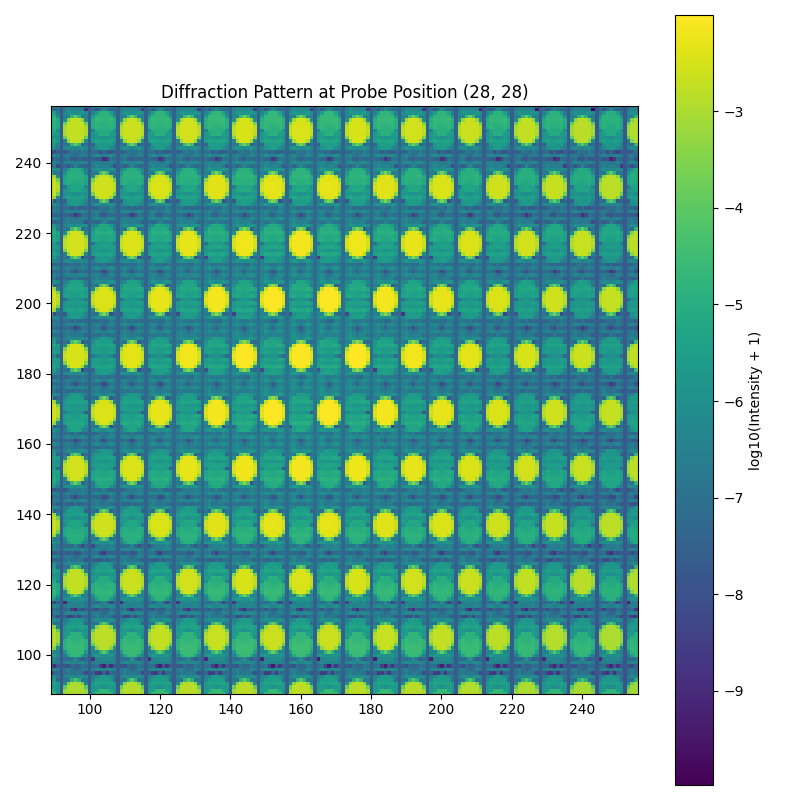

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(I_4d[4,4] + 1e-10), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.xlim(I_4d[0,0].shape[0]/2-96, I_4d[0,0].shape[1]/2+96)
plt.ylim(I_4d[0,0].shape[0]/2-96, I_4d[0,0].shape[1]/2+96)

plt.tight_layout()
plt.show()

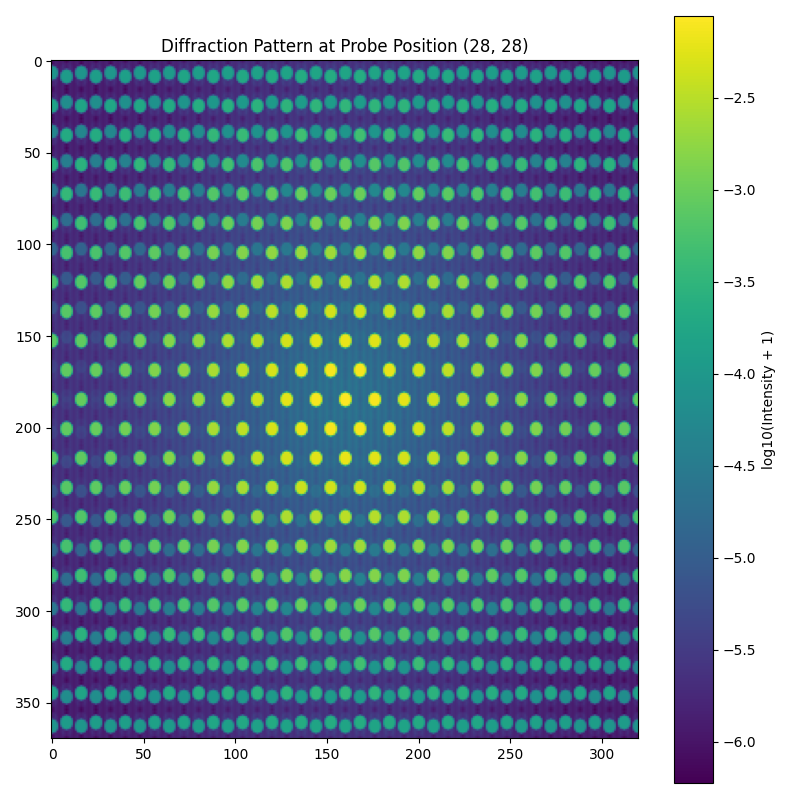

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(np.abs(I2_4d.mean(axis=(0,1))) + 1e-15), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()

plt.show()

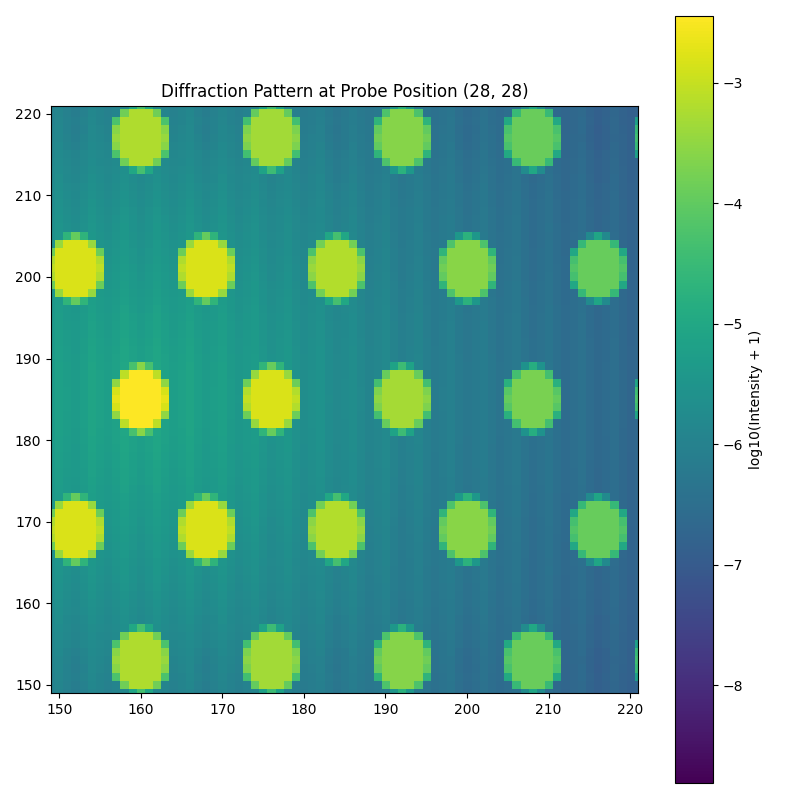

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(np.abs(I1_4d.mean(axis=(0,1))) + 1e-15), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()
plt.xlim(I10_4d.mean(axis=(0,1)).shape[0]/2-36,I10_4d.mean(axis=(0,1)).shape[0]/2+36)
plt.ylim(I10_4d.mean(axis=(0,1)).shape[0]/2-36,I10_4d.mean(axis=(0,1)).shape[0]/2+36)
plt.show()

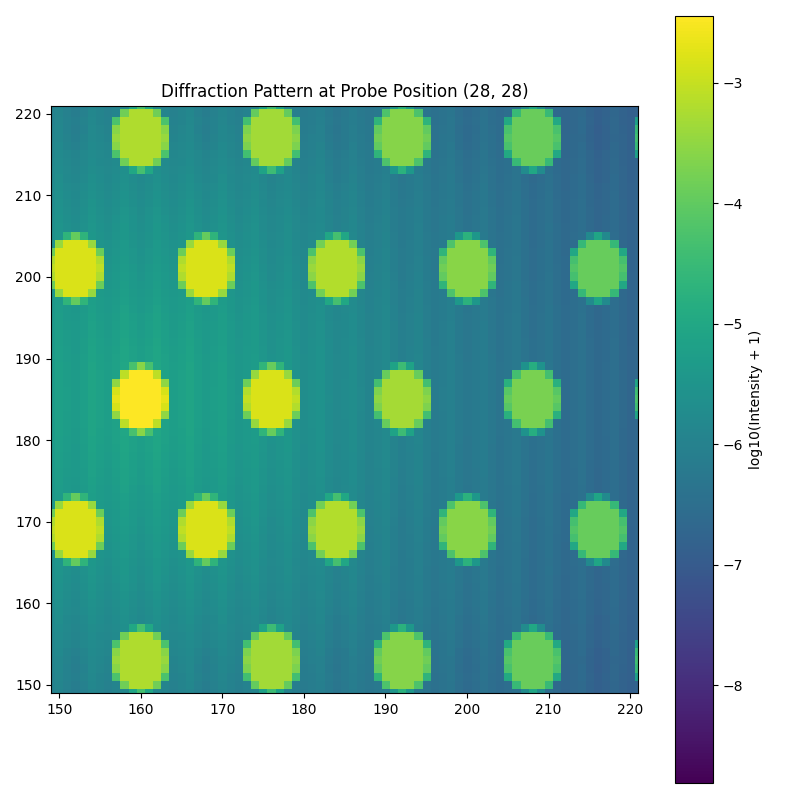

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(np.log10(np.abs(I1_4d.mean(axis=(0,1))) + 1e-15), cmap='viridis')
ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
plt.colorbar(im, ax=ax, label='log10(Intensity + 1)')
plt.tight_layout()
plt.xlim(I10_4d.mean(axis=(0,1)).shape[0]/2-36,I10_4d.mean(axis=(0,1)).shape[0]/2+36)
plt.ylim(I10_4d.mean(axis=(0,1)).shape[0]/2-36,I10_4d.mean(axis=(0,1)).shape[0]/2+36)
plt.show()

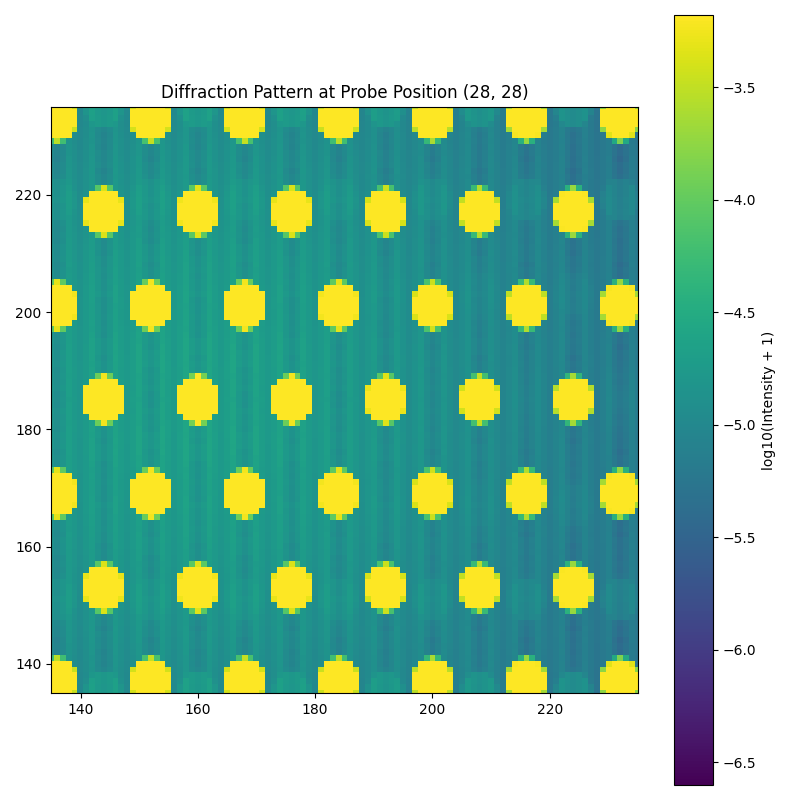

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

data = np.log10(np.abs(I2_4d.mean(axis=(0, 1))) + 1e-15)

im = ax.imshow(data, cmap='viridis', vmin=-3.18, vmax=-6)

ax.set_title('Diffraction Pattern at Probe Position (28, 28)')
fig.colorbar(im, ax=ax, label='log10(Intensity + 1)')

# compute center
center = data.shape[0] / 2

ax.set_xlim(center - 50, center + 50)
ax.set_ylim(center - 50, center + 50)

plt.tight_layout()
plt.show()
